# just imports and config here

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/aqi-env/bin/python


In [2]:
import subprocess
result = subprocess.run([sys.executable, '-m', 'pip', 'list'], capture_output=True, text=True)
print(result.stdout)

Package                 Version
----------------------- -----------
annotated-doc           0.0.4
annotated-types         0.7.0
anyio                   4.13.0
appnope                 0.1.4
asttokens               3.0.1
click                   8.3.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fastapi                 0.135.3
fonttools               4.62.1
h11                     0.16.0
idna                    3.11
ipykernel               7.2.0
ipython                 9.12.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
narwhals                2.18.1
nest-asyncio            1.6.0
numpy                   2.4.4
packaging               26.0
pandas                 

In [3]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 
                'pandas', 'numpy', 'matplotlib', 'seaborn', 
                'plotly', 'fastapi', 'uvicorn', 'scikit-learn', 'python-dotenv'])

CompletedProcess(args=['/opt/anaconda3/envs/aqi-env/bin/python', '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'fastapi', 'uvicorn', 'scikit-learn', 'python-dotenv'], returncode=0)

# actual code starts over here

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
%matplotlib inline

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [7]:
print('All imports successful!')

All imports successful!


In [8]:
# Load the CSV into a DataFrame
df = pd.read_csv('../server/data/city_day.csv')
# .head() shows the first 5 rows
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
# How many rows and columns?
print(f'Shape: {df.shape}') # (rows, columns)

Shape: (29531, 16)


In [10]:
# Column names and data types
print(df.dtypes)

City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object


In [12]:
# Summary statistics for numeric columns
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [14]:
missing = df.isnull().sum()
missing_pct = (missing/ len(df) * 100).round(2)

missing_report = pd.DataFrame({
'Missing Count': missing,
'Missing %': missing_pct
})

missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %',
ascending=False)

,Missing Count,Missing %
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


In [16]:
# Convert the Date column from string to actual datetime
# This lets us do time-based filtering and sorting later
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b') # Jan, Feb, Mar...
print(df['Date'].dtype) # Should now say: datetime64[ns]
df[['Date', 'Year', 'Month', 'Month_Name']].head()

datetime64[us]


,Date,Year,Month,Month_Name
0,2015-01-01,2015,1,Jan
1,2015-01-02,2015,1,Jan
2,2015-01-03,2015,1,Jan
3,2015-01-04,2015,1,Jan
4,2015-01-05,2015,1,Jan


In [19]:
# cities in the dataset
city_counts = df['City'].value_counts()
print(f'Total cities: {len(city_counts)}')
print(city_counts)

Total cities: 26
City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Delhi                 2009
Lucknow               2009
Mumbai                2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Ernakulam              162
Kochi                  162
Aizawl                 113
Name: count, dtype: int64


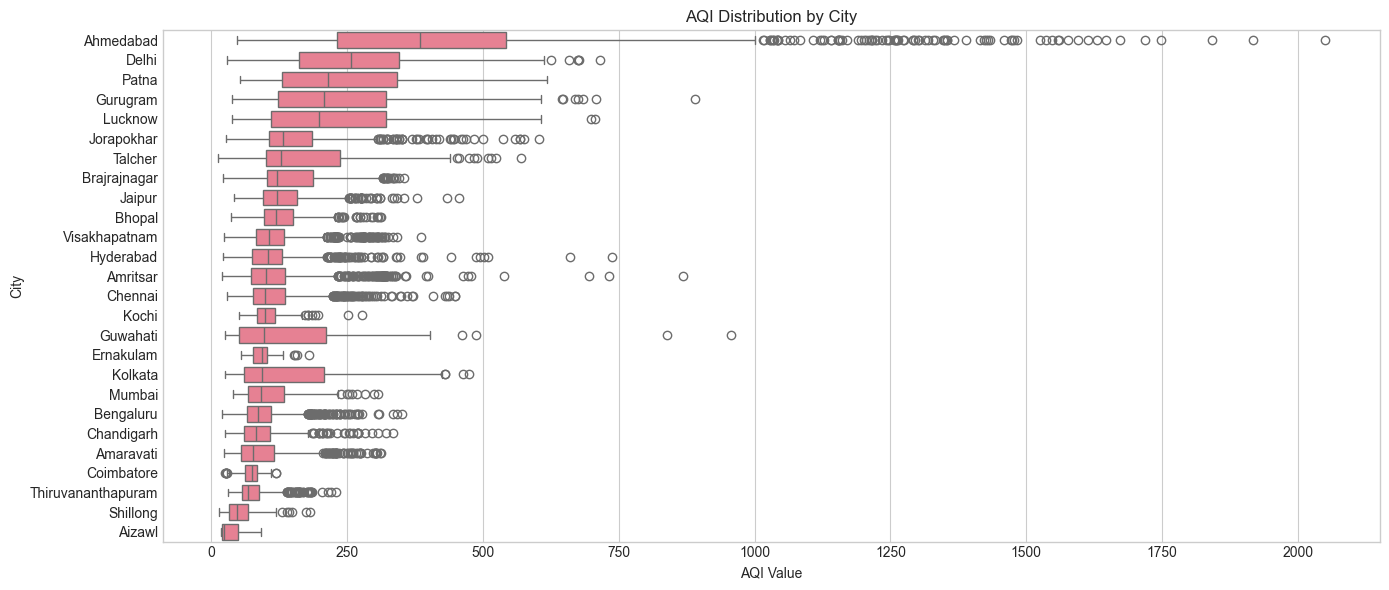

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Sort cities by median AQI (worst at top)
city_order = df.groupby('City')['AQI'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='AQI', y='City', order=city_order, ax=ax)

ax.set_title('AQI Distribution by City')
ax.set_xlabel('AQI Value')
plt.tight_layout()
plt.show()

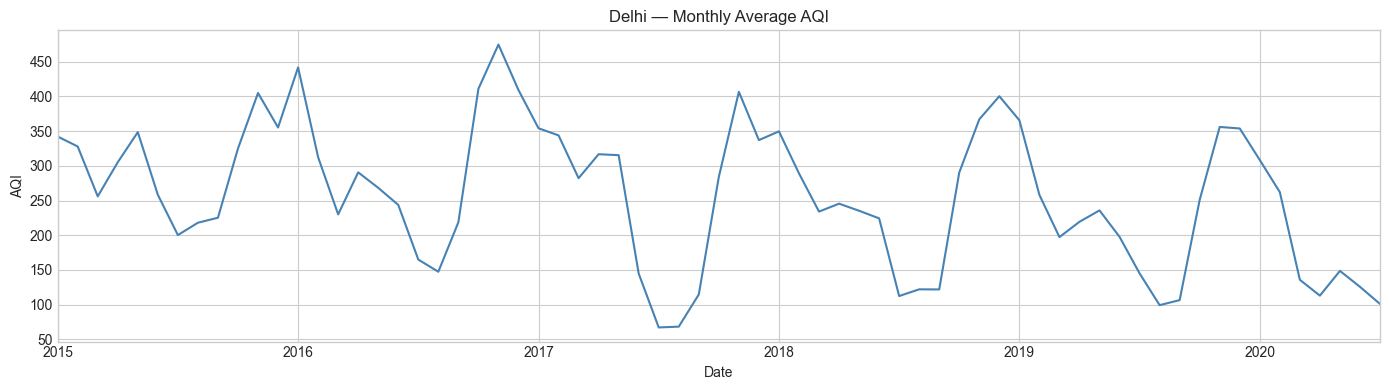

In [22]:
# Let's look at Delhi as an example
delhi = df[df['City'] == 'Delhi'].copy()
delhi = delhi.sort_values('Date')
# Monthly average AQI for Delhi
delhi_monthly = delhi.resample('ME', on='Date')['AQI'].mean()
fig, ax = plt.subplots(figsize=(14, 4))
delhi_monthly.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Delhi — Monthly Average AQI')
ax.set_ylabel('AQI')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

In [24]:
# Save a per-city summary to use later
city_summary = df.groupby('City')['AQI'].agg(['mean', 'median', 'min', 'max',
'count'])
city_summary.columns = ['Mean AQI', 'Median AQI', 'Min AQI', 'Max AQI', 'Records']
city_summary = city_summary.sort_values('Median AQI', ascending=False)
city_summary.to_csv('../server/data/city_summary.csv')
city_summary

,Mean AQI,Median AQI,Min AQI,Max AQI,Records
City,,,,,
Ahmedabad,452.122939,384.5,48.0,2049.0,1334
Delhi,259.487744,257.0,29.0,716.0,1999
Patna,240.782042,215.0,53.0,619.0,1459
Gurugram,225.123882,208.0,38.0,891.0,1453
Lucknow,217.973059,198.0,39.0,707.0,1893
Jorapokhar,159.251621,133.0,27.0,604.0,771
Talcher,172.886819,128.5,13.0,570.0,698
Brajrajnagar,150.280505,122.0,22.0,355.0,713
Jaipur,133.679159,122.0,43.0,457.0,1094
